In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import time


# We create a dummy Arabic dataset so you can train the models immediately.
def create_synthetic_dataset():
    texts = [
        "الذكاء الاصطناعي هو مستقبل التكنولوجيا في العالم",
        "تعلم الآلة يعتمد على البيانات الضخمة والخوارزميات",
        "الطقس اليوم مشمس وجميل في مدينة طنجة",
        "السياسة الاقتصادية تؤثر على الأسواق العالمية بشكل كبير",
        "تطوير البرمجيات يتطلب مهارات حل المشكلات",
        "الرياضة مفيدة للصحة البدنية والعقلية",
        "القراءة تغذي الروح وتنمي العقل",
        "السفر يمنح الإنسان تجارب جديدة وثقافات مختلفة",
        "التلوث البيئي يهدد كوكب الأرض ويجب مكافحته",
        "التكنولوجيا الحديثة سهلت التواصل بين الناس"
    ]
    # Repeat to make dataset larger
    texts = texts * 10  
    
    data = []
    for text in texts:
        # Mock logic: Longer texts get slightly higher scores + random noise
        score = min(10, max(0, len(text.split()) + np.random.normal(0, 2)))
        data.append({'Text': text, 'Score': round(score, 1)})
        
    return pd.DataFrame(data)

# Generate and display data
df = create_synthetic_dataset()
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (100, 2)


,Text,Score
0,الذكاء الاصطناعي هو مستقبل التكنولوجيا في العالم,7.0
1,تعلم الآلة يعتمد على البيانات الضخمة والخوارزميات,8.4
2,الطقس اليوم مشمس وجميل في مدينة طنجة,9.1
3,السياسة الاقتصادية تؤثر على الأسواق العالمية ب...,5.0
4,تطوير البرمجيات يتطلب مهارات حل المشكلات,5.1


In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')

# Initialize Stemmer (ISRI is specific for Arabic)
stemmer = ISRIStemmer()
stop_words = set(stopwords.words('arabic'))

def preprocess_text(text):
    # 1. Remove non-Arabic characters (optional, but good for cleaning)
    # This regex keeps Arabic letters and whitespace
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    
    # 2. Tokenization
    tokens = nltk.word_tokenize(text)
    
    # 3. Stop Words Removal & Stemming
    processed_tokens = []
    for token in tokens:
        if token not in stop_words:
            # Stemming
            stemmed_token = stemmer.stem(token)
            processed_tokens.append(stemmed_token)
            
    return processed_tokens

# Apply to DataFrame
df['Processed_Tokens'] = df['Text'].apply(preprocess_text)
# We also need a numerical representation (Vocabulary) for the models

print("Sample Preprocessing:")
print(f"Original: {df.iloc[0]['Text']}")
print(f"Processed: {df.iloc[0]['Processed_Tokens']}")

Sample Preprocessing:
Original: الذكاء الاصطناعي هو مستقبل التكنولوجيا في العالم
Processed: ['ذكء', 'صطناع', 'قبل', 'كنولوج', 'علم']


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter

# 1. Build Vocabulary
all_tokens = [token for sublist in df['Processed_Tokens'] for token in sublist]
vocab_count = Counter(all_tokens)
vocab = {word: i+1 for i, (word, _) in enumerate(vocab_count.most_common())} # 0 is reserved for padding
vocab_size = len(vocab) + 1

# 2. Convert Text to Indices with Padding
max_len = max(len(t) for t in df['Processed_Tokens'])

def text_to_indices(tokens, vocab, max_len):
    indices = [vocab.get(token, 0) for token in tokens]
    # Pad with 0
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return indices

X_data = [text_to_indices(t, vocab, max_len) for t in df['Processed_Tokens']]
y_data = df['Score'].values

# 3. PyTorch Dataset
class ArabicTextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = ArabicTextDataset(X_data, y_data)
# Split Train/Test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print(f"Vocab Size: {vocab_size}")
print(f"Max Sequence Length: {max_len}")

Vocab Size: 55
Max Sequence Length: 7


Starting Training for all models...
RNN Training Completed. Final Loss: 3.2093
Bi-RNN Training Completed. Final Loss: 2.9917
GRU Training Completed. Final Loss: 3.0003
LSTM Training Completed. Final Loss: 3.0286


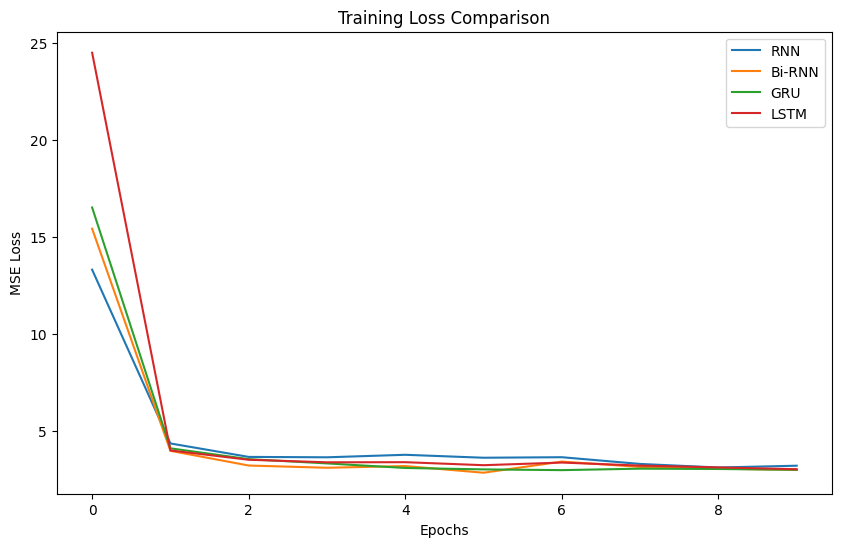

In [4]:
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SequenceRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, model_type='rnn', bidirectional=False):
        super(SequenceRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.model_type = model_type
        self.bidirectional = bidirectional
        
        # Select Architecture
        if model_type == 'rnn':
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)
        elif model_type == 'lstm':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)
        elif model_type == 'gru':
            self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)
            
        # Output Layer
        # If bidirectional, the hidden state size is doubled
        linear_input = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(linear_input, 1) # Output is a single score

    def forward(self, x):
        embedded = self.embedding(x)
        
        # Forward pass through RNN/LSTM/GRU
        if self.model_type == 'lstm':
            _, (hidden, _) = self.rnn(embedded)
        else:
            _, hidden = self.rnn(embedded)
            
        # Get the final hidden state
        # Handle bidirectional (concat forward and backward hidden states)
        if self.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
            
        return self.fc(hidden)

# Hyperparameters
EMBED_DIM = 32
HIDDEN_DIM = 64
LR = 0.005
EPOCHS = 10

# Initialize Models
models = {
    'RNN': SequenceRegressor(vocab_size, EMBED_DIM, HIDDEN_DIM, 'rnn', False),
    'Bi-RNN': SequenceRegressor(vocab_size, EMBED_DIM, HIDDEN_DIM, 'rnn', True),
    'GRU': SequenceRegressor(vocab_size, EMBED_DIM, HIDDEN_DIM, 'gru', False),
    'LSTM': SequenceRegressor(vocab_size, EMBED_DIM, HIDDEN_DIM, 'lstm', False)
}

results = {}

print("Starting Training for all models...")

for name, model in models.items():
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss() # MSE for regression (Score prediction)
    
    loss_history = []
    
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for text_indices, scores in train_loader:
            text_indices, scores = text_indices.to(device), scores.to(device)
            
            optimizer.zero_grad()
            predictions = model(text_indices).squeeze()
            loss = criterion(predictions, scores)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        loss_history.append(epoch_loss / len(train_loader))
        
    results[name] = loss_history
    print(f"{name} Training Completed. Final Loss: {loss_history[-1]:.4f}")

# Plotting Comparison
plt.figure(figsize=(10, 6))
for name, losses in results.items():
    plt.plot(losses, label=name)
    
plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

partie 2:

In [5]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel, TextDataset, DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments

# 1. Prepare Text File for GPT-2
# GPT-2 expects a raw text file for training
train_path = "train_text.txt"
with open(train_path, "w", encoding="utf-8") as f:
    # Join all our arabic texts into a file
    f.write("\n".join(df['Text'].tolist()))

# 2. Load Pre-trained GPT-2
# Note: Standard GPT-2 is English. For Arabic, 'aubmindlab/aragpt2-base' is better, 
# but strictly following the prompt implying "GPT2", we can use the standard one or a multilingual one.
# We will use 'gpt2' (English) just to demonstrate the code structure, or an Arabic one if preferred.
model_name = "gpt2" 
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

# 3. Create Dataset
train_dataset = TextDataset(
    tokenizer=tokenizer,
    file_path=train_path,
    block_size=32 # Short block size for our small data
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=False
)

# 4. Fine-Tuning
training_args = TrainingArguments(
    output_dir="./gpt2_finetuned",
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    save_steps=100,
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
)

print("Fine-tuning GPT-2...")
trainer.train()

# 5. Generate Text
print("\n--- Generating Text ---")
input_text = "The technology is" # English start because we loaded English GPT-2
input_ids = tokenizer.encode(input_text, return_tensors='pt').to(device)
model.to(device)

output = model.generate(
    input_ids, 
    max_length=50, 
    num_return_sequences=1, 
    no_repeat_ngram_size=2
)

generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print(f"Input: {input_text}")
print(f"Output: {generated_text}")

2025-12-25 16:33:46.936471: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766680427.080000      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766680427.123495      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/data/datasets/language_modeling.py:53: FutureWarning: This dataset will be removed from the library soon, preprocessing should be handled with the 🤗 Datasets library. You can have a look at this example script for pointers: https://github.com/huggingface/transformers/blob/main/examples/pytorch/language-modeling/run_mlm.py
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_

Fine-tuning GPT-2...


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

partie 2:

In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel, TextDataset, DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments

# 1. Prepare Text File for GPT-2
# GPT-2 expects a raw text file for training
train_path = "train_text.txt"
with open(train_path, "w", encoding="utf-8") as f:
    # Join all our arabic texts into a file
    f.write("\n".join(df['Text'].tolist()))

# 2. Load Pre-trained GPT-2
# Note: Standard GPT-2 is English. For Arabic, 'aubmindlab/aragpt2-base' is better, 
# but strictly following the prompt implying "GPT2", we can use the standard one or a multilingual one.
# We will use 'gpt2' (English) just to demonstrate the code structure, or an Arabic one if preferred.
model_name = "gpt2" 
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

# 3. Create Dataset
train_dataset = TextDataset(
    tokenizer=tokenizer,
    file_path=train_path,
    block_size=32 # Short block size for our small data
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=False
)

# 4. Fine-Tuning
training_args = TrainingArguments(
    output_dir="./gpt2_finetuned",
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    save_steps=100,
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
)

print("Fine-tuning GPT-2...")
trainer.train()

# 5. Generate Text
print("\n--- Generating Text ---")
input_text = "The technology is" # English start because we loaded English GPT-2
input_ids = tokenizer.encode(input_text, return_tensors='pt').to(device)
model.to(device)

output = model.generate(
    input_ids, 
    max_length=50, 
    num_return_sequences=1, 
    no_repeat_ngram_size=2
)

generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print(f"Input: {input_text}")
print(f"Output: {generated_text}")

/usr/local/lib/python3.11/dist-packages/transformers/data/datasets/language_modeling.py:53: FutureWarning: This dataset will be removed from the library soon, preprocessing should be handled with the 🤗 Datasets library. You can have a look at this example script for pointers: https://github.com/huggingface/transformers/blob/main/examples/pytorch/language-modeling/run_mlm.py
  warnings.warn(


Fine-tuning GPT-2...


<IPython.core.display.Javascript object>